# Reading NetCDF File in Coastcomparedfinalpaper

This notebook demonstrates how to load the Copernicus Marine NetCDF file, convert it into a Pandas DataFrame, subset the first year, and calculate ocean current velocity and direction.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np

### Load the NetCDF file
We use `xarray.open_dataset` to load the `.nc` file efficiently.

In [2]:
nc_file = 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m_1780513629836.nc'
ds = xr.open_dataset(nc_file)
ds

<xarray.Dataset> Size: 12MB
Dimensions:    (time: 34345, depth: 1, latitude: 7, longitude: 6)
Coordinates:
  * time       (time) datetime64[ns] 275kB 2022-07-04T12:00:00 ... 2026-06-04...
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 28B 12.25 12.33 12.42 12.5 12.58 12.67 12.75
  * longitude  (longitude) float32 24B 69.75 69.83 69.92 70.0 70.08 70.17
Data variables:
    uo         (time, depth, latitude, longitude) float32 6MB ...
    vo         (time, depth, latitude, longitude) float32 6MB ...
Attributes:
    Conventions:       CF-1.11
    title:             hourly mean fields from Global Ocean Physics Analysis ...
    institution:       Mercator Ocean International
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            MOI GLO12
    credit:            E.U. Copernicus Marine Service Information (CMEMS)
    contact:           https://marine.copernicus.eu/contact
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_ANALYSISFORECAST_PHY_001_024
    subset:datasetId:  cmems_mod_glo_phy_anfc_0.083deg_PT1H-m_202406
    subset:date:       2026-06-03T19:07:09.843Z

### Convert to Pandas DataFrame
We can convert the dataset into a multi-index DataFrame using `.to_dataframe()`, and reset the index to flatten it.

In [3]:
df = ds.to_dataframe().reset_index()
df.head()

,time,depth,latitude,longitude,uo,vo
0,2022-07-04 12:00:00,0.494025,12.25,69.750015,0.046611,-0.145109
1,2022-07-04 12:00:00,0.494025,12.25,69.833351,0.042062,-0.156250
2,2022-07-04 12:00:00,0.494025,12.25,69.916679,0.052199,-0.154668
3,2022-07-04 12:00:00,0.494025,12.25,70.000015,0.073616,-0.138919
4,2022-07-04 12:00:00,0.494025,12.25,70.083351,0.108059,-0.122088


### Inspect DataFrame info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1442490 entries, 0 to 1442489
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   time       1442490 non-null  datetime64[ns]
 1   depth      1442490 non-null  float32       
 2   latitude   1442490 non-null  float32       
 3   longitude  1442490 non-null  float32       
 4   uo         1442490 non-null  float32       
 5   vo         1442490 non-null  float32       
dtypes: datetime64[ns](1), float32(5)
memory usage: 38.5 MB


### Subset the first year of data
We subset the first calendar year of data (2022) by filtering the DataFrame based on the minimum year present in the `time` column. We use `.copy()` to avoid pandas warnings when modifying the subsetted DataFrame later.

In [5]:
# Ensure time column is datetime objects
df['time'] = pd.to_datetime(df['time'])

# Subset the first calendar year (2022) as a copy
first_year = df['time'].dt.year.min()
year1 = df[df['time'].dt.year == first_year].copy()

print(f"Subsetted first year ({first_year}) shape: {year1.shape}")
year1.head()

Subsetted first year (2022) shape: (181944, 6)


,time,depth,latitude,longitude,uo,vo
0,2022-07-04 12:00:00,0.494025,12.25,69.750015,0.046611,-0.145109
1,2022-07-04 12:00:00,0.494025,12.25,69.833351,0.042062,-0.156250
2,2022-07-04 12:00:00,0.494025,12.25,69.916679,0.052199,-0.154668
3,2022-07-04 12:00:00,0.494025,12.25,70.000015,0.073616,-0.138919
4,2022-07-04 12:00:00,0.494025,12.25,70.083351,0.108059,-0.122088


### Calculate Velocity and Direction of the Currents
We calculate the current speed (magnitude) and direction (in degrees relative to North) using the Eastward (`uo`) and Northward (`vo`) components of sea water velocity.

In [6]:
# 1. Calculate Vector Magnitude (Sea Water Speed) 
# Speed = sqrt(uo^2 + vo^2)
year1['speed'] = np.sqrt(year1['uo']**2 + year1['vo']**2)

# 2. Calculate Vector Direction in Degrees (Oceanographic convention)
# Returns angles relative to North (0° = North, 90° = East)
sea_water_dir = np.degrees(np.arctan2(year1['uo'], year1['vo']))
year1['direction'] = (sea_water_dir + 360) % 360  # Ensure all values are 0-360°

print("Velocity and direction calculation complete!")
year1[['time', 'latitude', 'longitude', 'uo', 'vo', 'speed', 'direction']].head()

Velocity and direction calculation complete!


,time,latitude,longitude,uo,vo,speed,direction
0,2022-07-04 12:00:00,12.25,69.750015,0.046611,-0.145109,0.152411,162.192078
1,2022-07-04 12:00:00,12.25,69.833351,0.042062,-0.156250,0.161813,164.933472
2,2022-07-04 12:00:00,12.25,69.916679,0.052199,-0.154668,0.163238,161.351013
3,2022-07-04 12:00:00,12.25,70.000015,0.073616,-0.138919,0.157219,152.080078
4,2022-07-04 12:00:00,12.25,70.083351,0.108059,-0.122088,0.163041,138.488403


In [9]:
# 1. View DataFrame structure (columns, non-null counts, data types, and memory usage)
print("--- DataFrame Info ---")
year1.info()

print("\n" + "="*50 + "\n")

# 2. View statistical summary (min, max, mean, std, percentiles)
print("--- Summary Statistics ---")
display(year1.describe())

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 181944 entries, 0 to 181943
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   time       181944 non-null  datetime64[ns]
 1   depth      181944 non-null  float32       
 2   latitude   181944 non-null  float32       
 3   longitude  181944 non-null  float32       
 4   uo         181944 non-null  float32       
 5   vo         181944 non-null  float32       
 6   speed      181944 non-null  float32       
 7   direction  181944 non-null  float32       
dtypes: datetime64[ns](1), float32(7)
memory usage: 6.2 MB


--- Summary Statistics ---


,time,depth,latitude,longitude,uo,vo,speed,direction
count,181944,181944.000000,181944.000000,181944.000000,181944.000000,181944.000000,181944.000000,181944.000000
mean,2022-10-02 17:30:00.000000256,0.494025,12.500000,69.958351,0.006499,-0.007757,0.222052,178.483978
min,2022-07-04 12:00:00,0.494025,12.250000,69.750015,-0.589350,-0.476006,0.000538,0.006744
25%,2022-08-18 14:45:00,0.494025,12.333333,69.833351,-0.068868,-0.169497,0.150126,118.923599
50%,2022-10-02 17:30:00,0.494025,12.500000,69.958347,0.018253,-0.039891,0.215342,169.998108
75%,2022-11-16 20:15:00,0.494025,12.666667,70.083351,0.101387,0.146897,0.282869,270.957451
max,2022-12-31 23:00:00,0.494025,12.750000,70.166679,0.478410,0.565142,0.640680,359.993408
std,NaN,0.000000,0.166667,0.142319,0.149777,0.191940,0.100345,101.079643


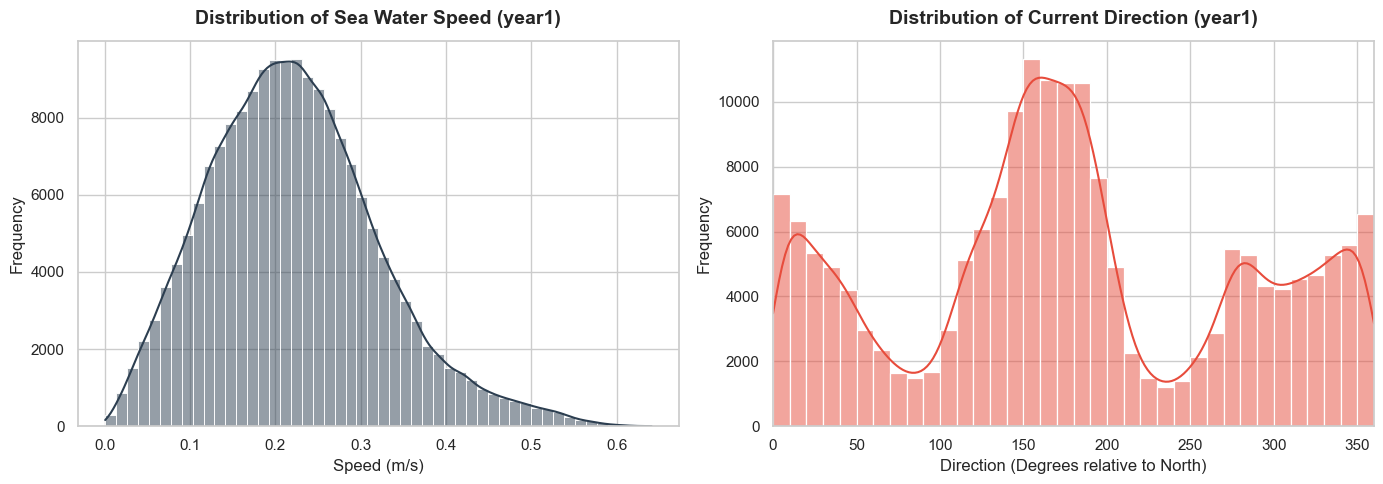

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram for Current Speed (m/s)
sns.histplot(data=year1, x='speed', bins=50, kde=True, ax=axes[0], color='#2c3e50')
axes[0].set_title('Distribution of Sea Water Speed (year1)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Speed (m/s)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# 2. Histogram for Current Direction (Degrees)
sns.histplot(data=year1, x='direction', bins=36, kde=True, ax=axes[1], color='#e74c3c')
axes[1].set_title('Distribution of Current Direction (year1)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Direction (Degrees relative to North)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(0, 360)

plt.tight_layout()
plt.show()

In [11]:
# Ensure time column is datetime objects
df['time'] = pd.to_datetime(df['time'])

# Define start date of the dataset
start_date = df['time'].min()

# Define 12-month boundary offsets
y1_end = start_date + pd.DateOffset(years=1)
y2_end = start_date + pd.DateOffset(years=2)
y3_end = start_date + pd.DateOffset(years=3)

# Subset into distinct copies
year1 = df[(df['time'] >= start_date) & (df['time'] < y1_end)].copy()
year2 = df[(df['time'] >= y1_end) & (df['time'] < y2_end)].copy()
year3 = df[(df['time'] >= y2_end) & (df['time'] < y3_end)].copy()
year4 = df[(df['time'] >= y3_end)].copy()  # Spans the remaining 11 months

# Print range and shapes
for i, y_df in enumerate([year1, year2, year3, year4], 1):
    label = f"Year {i}" if i < 4 else "Year 4 (11 months)"
    print(f"{label}: {y_df['time'].min()} to {y_df['time'].max()} | Shape: {y_df.shape}")

Year 1: 2022-07-04 12:00:00 to 2023-07-04 11:00:00 | Shape: (367920, 6)
Year 2: 2023-07-04 12:00:00 to 2024-07-04 11:00:00 | Shape: (368928, 6)
Year 3: 2024-07-04 12:00:00 to 2025-07-04 11:00:00 | Shape: (367920, 6)
Year 4 (11 months): 2025-07-04 12:00:00 to 2026-06-04 12:00:00 | Shape: (337722, 6)


In [12]:
years_dfs = [year1, year2, year3, year4]

for i, y_df in enumerate(years_dfs, 1):
    # 1. Calculate Vector Magnitude (Sea Water Speed)
    y_df['speed'] = np.sqrt(y_df['uo']**2 + y_df['vo']**2)

    # 2. Calculate Vector Direction in Degrees (Oceanographic convention)
    sea_water_dir = np.degrees(np.arctan2(y_df['uo'], y_df['vo']))
    y_df['direction'] = (sea_water_dir + 360) % 360  # Ensure all values are 0-360°
    
    print(f"Year {i} calculation complete!")

Year 1 calculation complete!
Year 2 calculation complete!
Year 3 calculation complete!
Year 4 calculation complete!


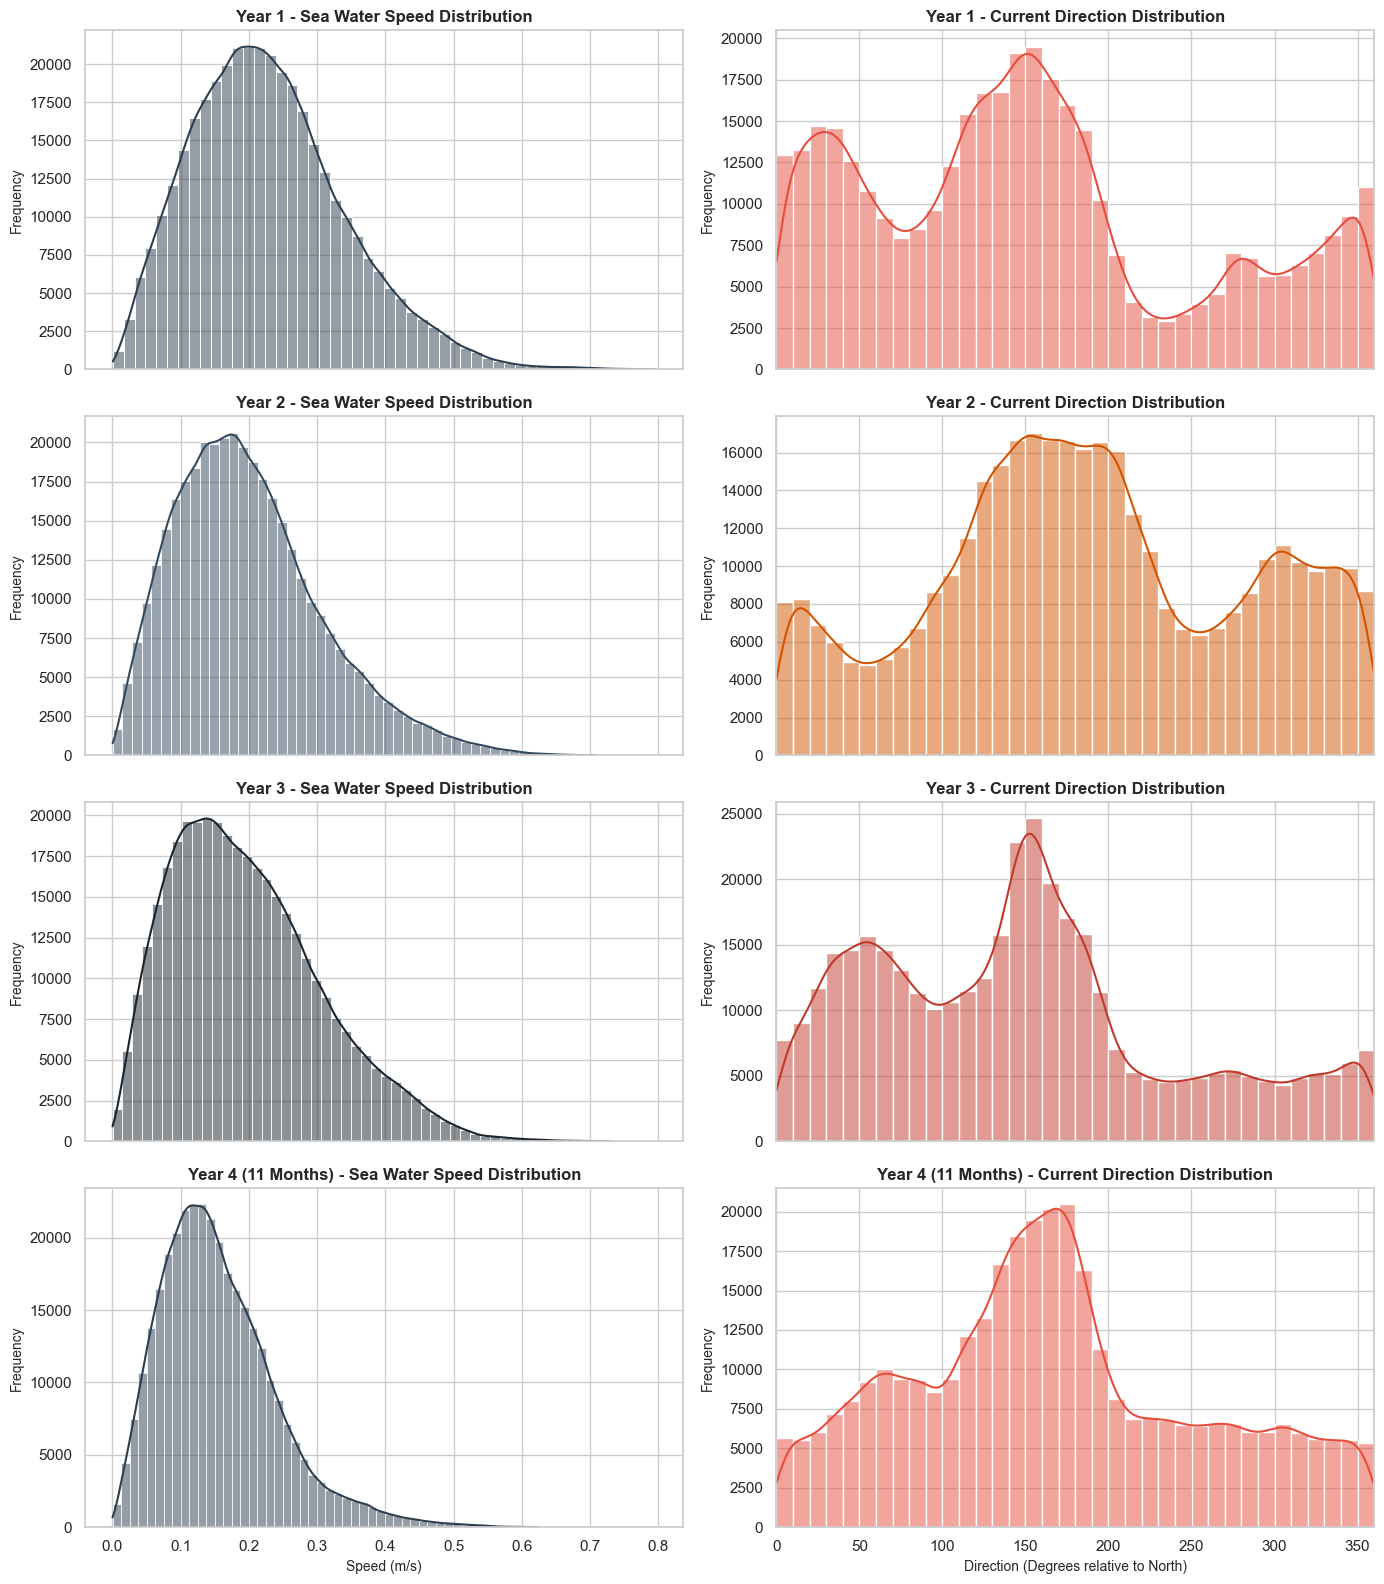

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Create a 4x2 grid of subplots (4 years, 2 metrics)
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex='col')

# Colors for visual separation
colors_speed = ['#2c3e50', '#34495e', '#1a252f', '#2c3e50']
colors_dir = ['#e74c3c', '#d35400', '#c0392b', '#e74c3c']
years_dfs = [year1, year2, year3, year4]

for i, y_df in enumerate(years_dfs):
    # Set the labels appropriately
    year_label = f"Year {i+1}" if i < 3 else "Year 4 (11 Months)"
    
    # 1. Speed Histogram (Left Column)
    sns.histplot(data=y_df, x='speed', bins=50, kde=True, ax=axes[i, 0], color=colors_speed[i])
    axes[i, 0].set_title(f'{year_label} - Sea Water Speed Distribution', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('Speed (m/s)', fontsize=10)
    axes[i, 0].set_ylabel('Frequency', fontsize=10)
    
    # 2. Direction Histogram (Right Column)
    sns.histplot(data=y_df, x='direction', bins=36, kde=True, ax=axes[i, 1], color=colors_dir[i])
    axes[i, 1].set_title(f'{year_label} - Current Direction Distribution', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('Direction (Degrees relative to North)', fontsize=10)
    axes[i, 1].set_ylabel('Frequency', fontsize=10)
    axes[i, 1].set_xlim(0, 360)

plt.tight_layout()
plt.show()

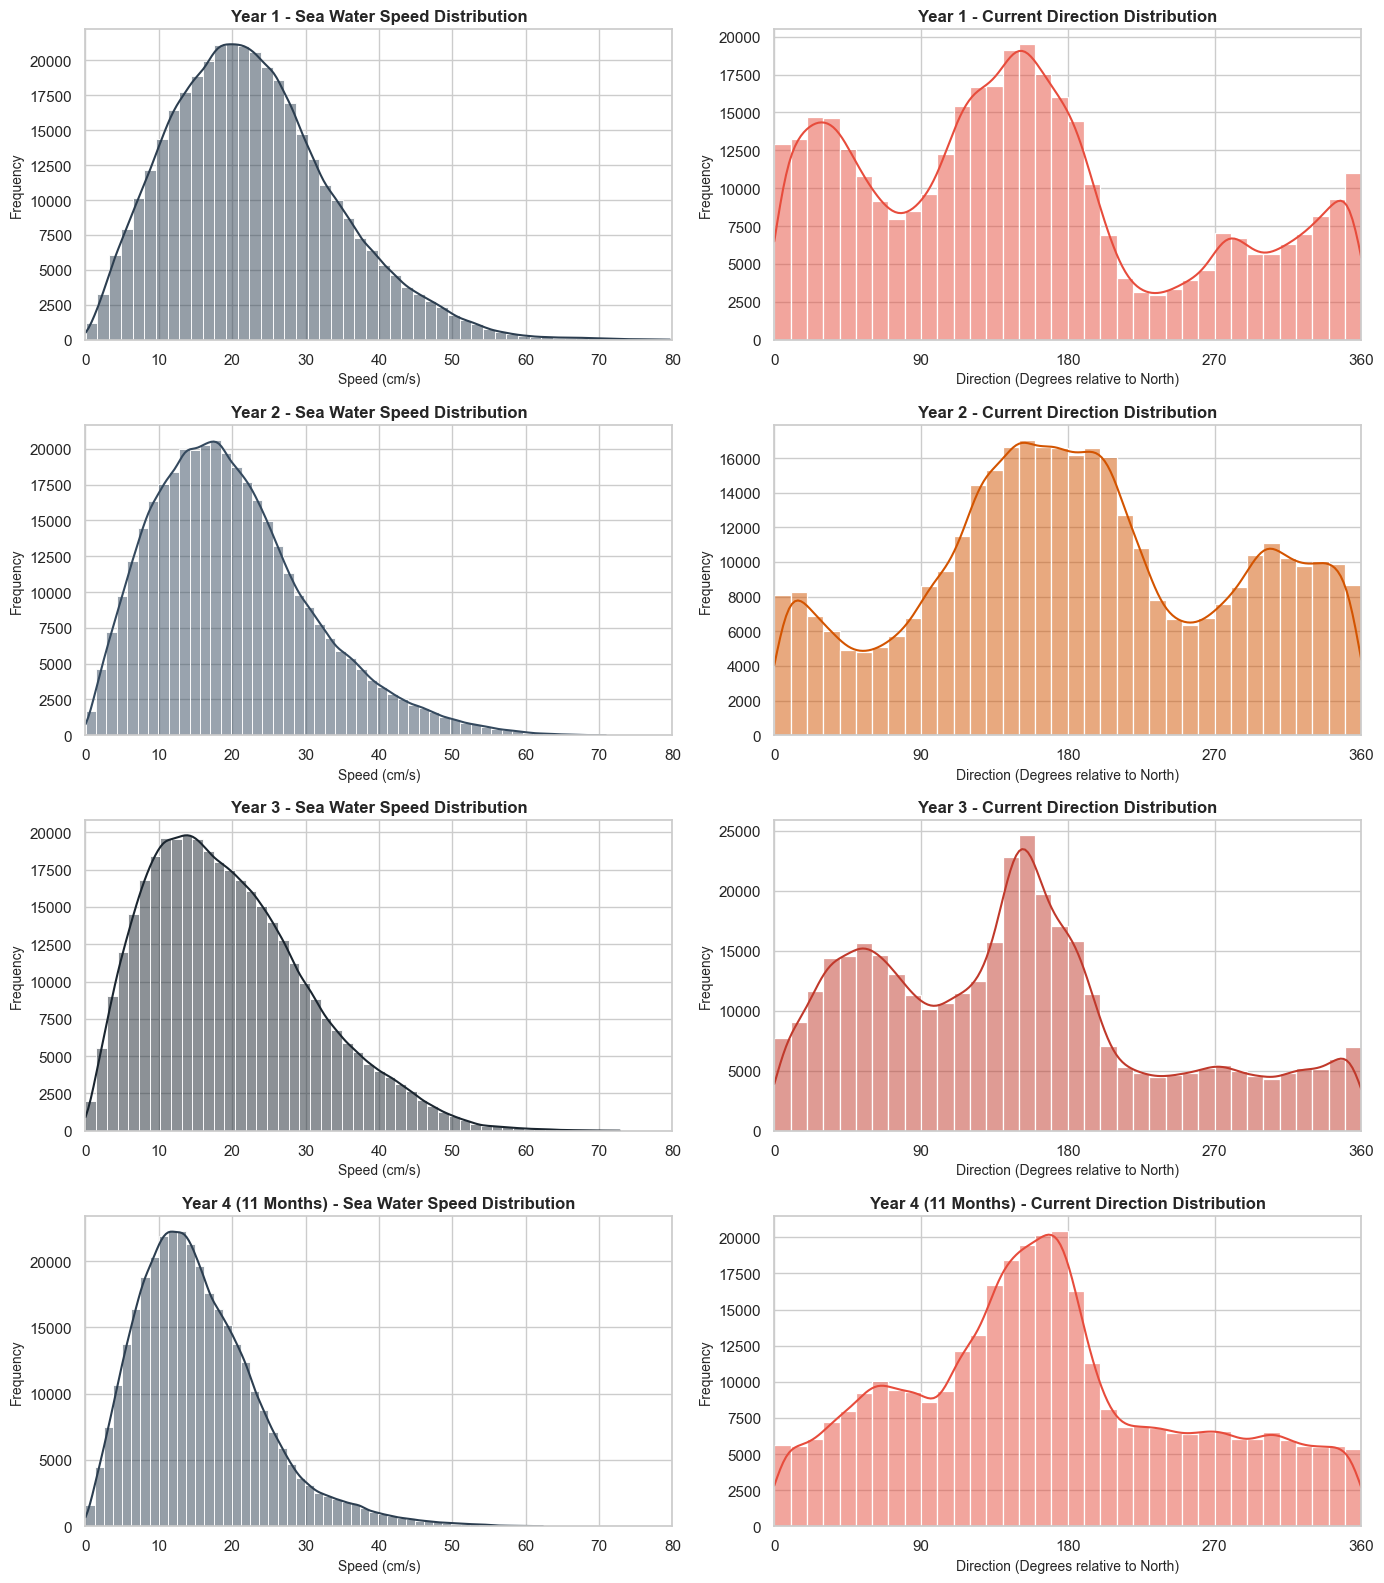

In [14]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create a 4x2 grid of subplots (4 years, 2 metrics)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

colors_speed = ['#2c3e50', '#34495e', '#1a252f', '#2c3e50']
colors_dir = ['#e74c3c', '#d35400', '#c0392b', '#e74c3c']

for i, y_df in enumerate(years_dfs):
    year_label = f"Year {i+1}" if i < 3 else "Year 4 (11 Months)"
    
    # 1. Convert Speed from m/s to cm/s for clean integer ticks
    y_df['speed_cms'] = y_df['speed'] * 100
    
    # Speed Histogram (Left Column)
    sns.histplot(data=y_df, x='speed_cms', bins=50, kde=True, ax=axes[i, 0], color=colors_speed[i])
    axes[i, 0].set_title(f'{year_label} - Sea Water Speed Distribution', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('Speed (cm/s)', fontsize=10)
    axes[i, 0].set_ylabel('Frequency', fontsize=10)
    axes[i, 0].set_xlim(0, 80)
    axes[i, 0].set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])
    
    # Direction Histogram (Right Column)
    sns.histplot(data=y_df, x='direction', bins=36, kde=True, ax=axes[i, 1], color=colors_dir[i])
    axes[i, 1].set_title(f'{year_label} - Current Direction Distribution', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('Direction (Degrees relative to North)', fontsize=10)
    axes[i, 1].set_ylabel('Frequency', fontsize=10)
    axes[i, 1].set_xlim(0, 360)
    axes[i, 1].set_xticks([0, 90, 180, 270, 360])

plt.tight_layout()
plt.show()

In [16]:
# Convert to DataFrame
df = ds.to_dataframe().reset_index()

# 1. Calculate Vector Magnitude (Sea Water Speed) in m/s
df['speed'] = np.sqrt(df['uo']**2 + df['vo']**2)

# 2. Convert Speed to cm/s for clean integer ticks on x-axis
df['speed_cms'] = df['speed'] * 100

# 3. Calculate Vector Direction in Degrees (Oceanographic convention: 0° = North, 90° = East)
sea_water_dir = np.degrees(np.arctan2(df['uo'], df['vo']))
df['direction'] = (sea_water_dir + 360) % 360  # Ensure all values are 0-360°

print("DataFrame loaded and vector calculations complete!")
df[['time', 'latitude', 'longitude', 'uo', 'vo', 'speed_cms', 'direction']].head()

DataFrame loaded and vector calculations complete!


,time,latitude,longitude,uo,vo,speed_cms,direction
0,2022-07-04 12:00:00,12.25,69.750015,0.046611,-0.145109,15.241133,162.192078
1,2022-07-04 12:00:00,12.25,69.833351,0.042062,-0.156250,16.181261,164.933472
2,2022-07-04 12:00:00,12.25,69.916679,0.052199,-0.154668,16.323835,161.351013
3,2022-07-04 12:00:00,12.25,70.000015,0.073616,-0.138919,15.721907,152.080078
4,2022-07-04 12:00:00,12.25,70.083351,0.108059,-0.122088,16.304052,138.488403


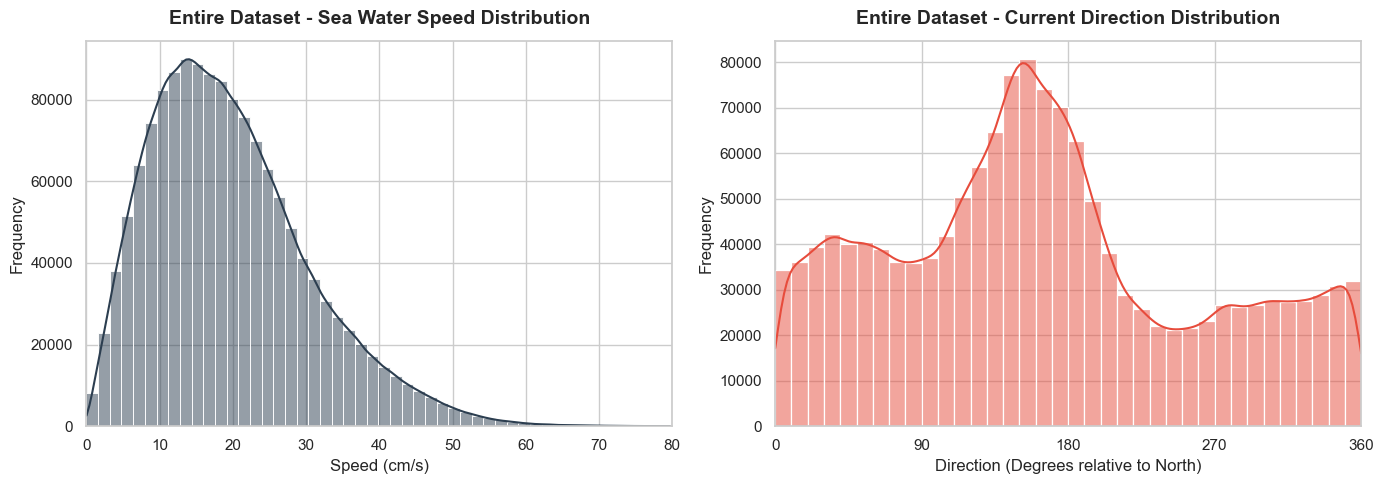

In [17]:
# Set visual style
sns.set_theme(style="whitegrid")

# Create side-by-side plots for the entire dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Speed Histogram
sns.histplot(data=df, x='speed_cms', bins=50, kde=True, ax=axes[0], color='#2c3e50')
axes[0].set_title('Entire Dataset - Sea Water Speed Distribution', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Speed (cm/s)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_xlim(0, 80)
axes[0].set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80])

# 2. Direction Histogram
sns.histplot(data=df, x='direction', bins=36, kde=True, ax=axes[1], color='#e74c3c')
axes[1].set_title('Entire Dataset - Current Direction Distribution', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Direction (Degrees relative to North)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(0, 360)
axes[1].set_xticks([0, 90, 180, 270, 360])

plt.tight_layout()
plt.show()

C:\Users\chris\AppData\Local\Temp\ipykernel_42972\3785158045.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year_month', y='speed_cms', ax=axes[0], palette='crest', order=sorted_months)
C:\Users\chris\AppData\Local\Temp\ipykernel_42972\3785158045.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\chris\AppData\Local\Temp\ipykernel_42972\3785158045.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year_month', y='direction', ax=axes[1], palette='flare', order=sorted_months)
C:\Users\chris\Ap

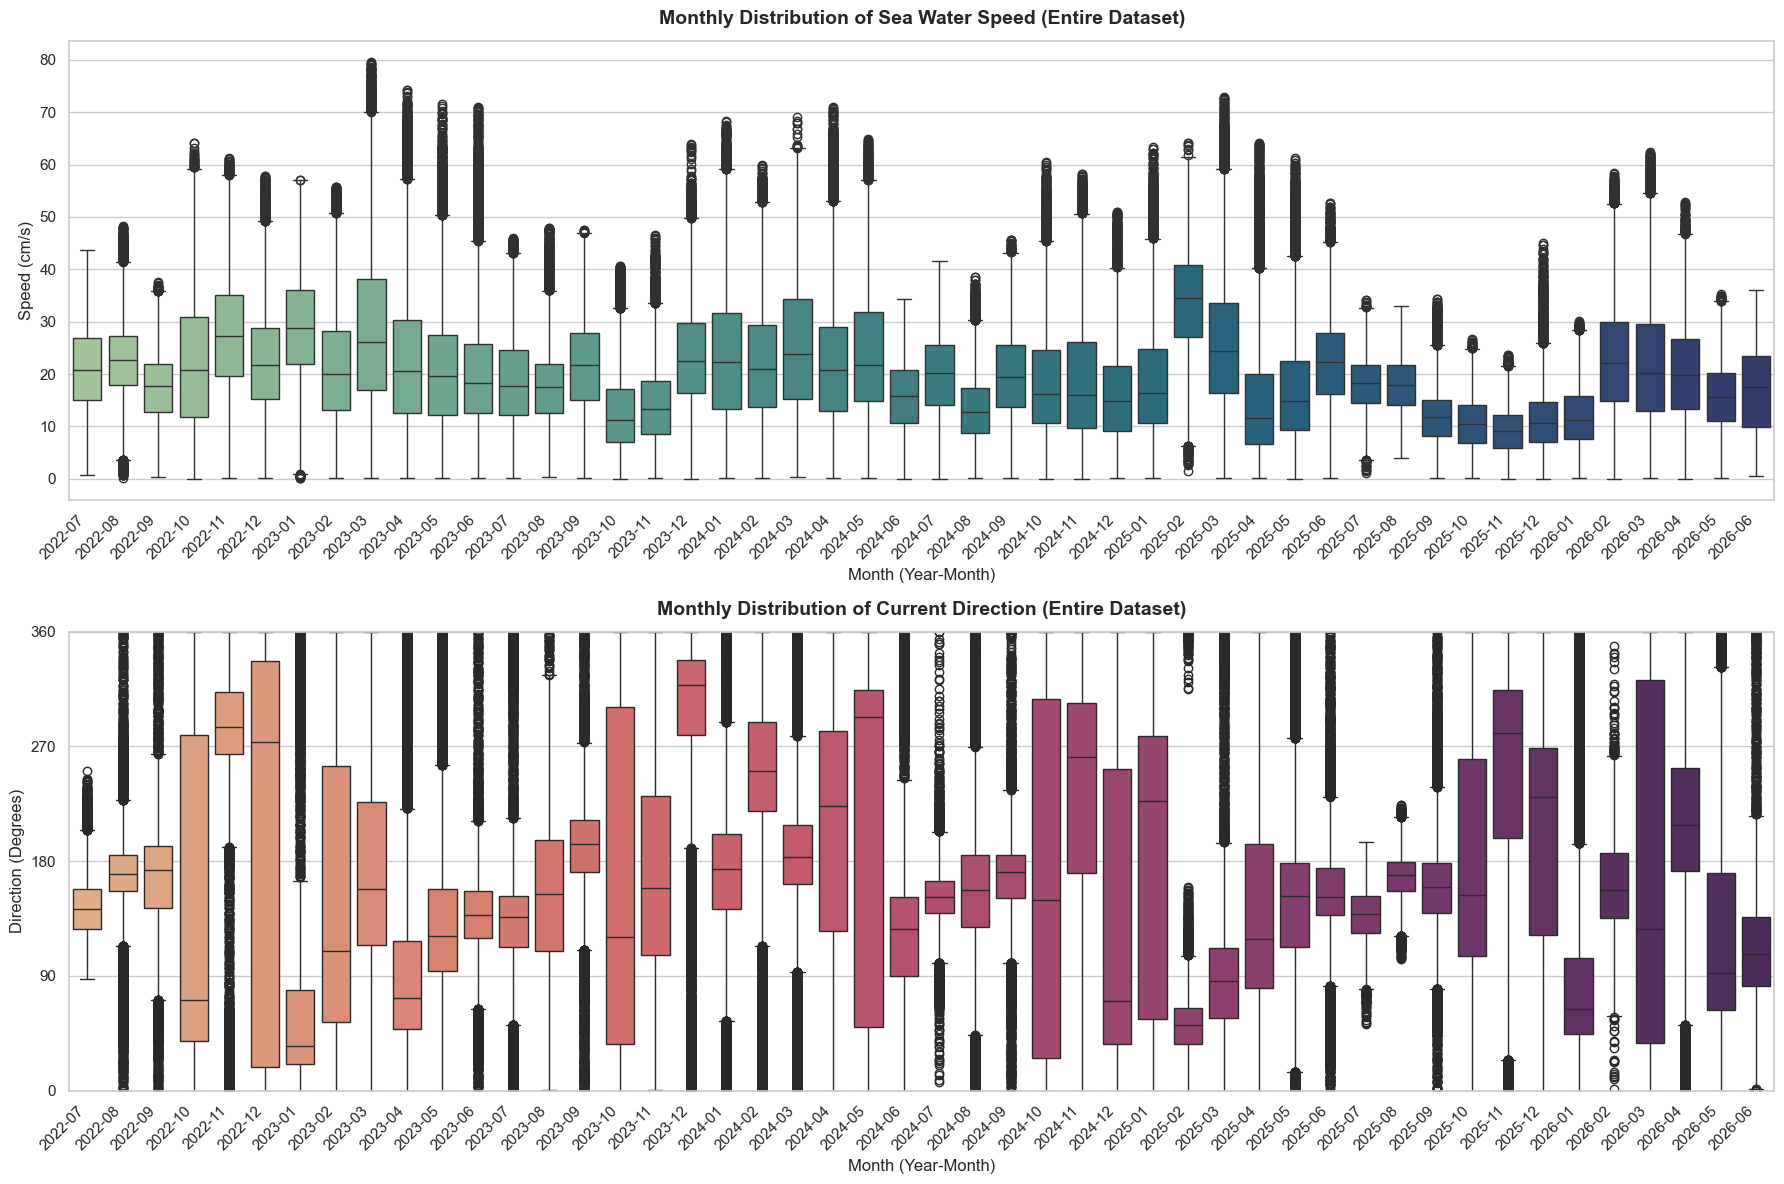

In [18]:
# Create a sorted Year-Month string column for chronological grouping
df['year_month'] = df['time'].dt.strftime('%Y-%m')
sorted_months = sorted(df['year_month'].unique())

# Setup figure with 2 rows (Speed & Direction)
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# 1. Box plot for Speed (cm/s) grouped by month
sns.boxplot(data=df, x='year_month', y='speed_cms', ax=axes[0], palette='crest', order=sorted_months)
axes[0].set_title('Monthly Distribution of Sea Water Speed (Entire Dataset)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Month (Year-Month)', fontsize=12)
axes[0].set_ylabel('Speed (cm/s)', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# 2. Box plot for Direction (Degrees) grouped by month
sns.boxplot(data=df, x='year_month', y='direction', ax=axes[1], palette='flare', order=sorted_months)
axes[1].set_title('Monthly Distribution of Current Direction (Entire Dataset)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Month (Year-Month)', fontsize=12)
axes[1].set_ylabel('Direction (Degrees)', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylim(0, 360)
axes[1].set_yticks([0, 90, 180, 270, 360])

plt.tight_layout()
plt.show()